# IMPLEMENTING EXPLAINABLE AI TECNIQUES

### Name : Darshan Ganesh Bhabad
### Prn : 202301040169


### Kaggle Notebook Implementaion Url : (https://www.kaggle.com/code/bboyattitude/implementing-explainable-ai-techniques?scriptVersionId=311761237)

### Github Repo Link : (https://github.com/DarshanBhabad/Implementing-Explainable-AI-Techniques)

## 1) Install Necessary Libraries

In [1]:
!pip install tf-explain shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.5 MB/s eta 0:00:00


## 2) Imports and Data Preprocessing

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# 1. Load Dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# 2. Normalize pixel values to [0, 1]
x_train, x_test = x_train / 255.0, x_test / 255.0

# 3. One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Data loaded: x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")

2026-04-15 10:25:37.824233: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776248738.237380      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776248738.348590      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776248739.289582      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776248739.289626      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776248739.289629      23 computation_placer.cc:177] computation placer alr

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Data loaded: x_train shape: (50000, 32, 32, 3), y_train shape: (50000, 1)


## 3) CNN Model Implementation

In [3]:
def build_model_functional():
    # 1. Define Input
    inputs = tf.keras.Input(shape=(32, 32, 3))
    
    # 2. Add Layers
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3, 3), activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Name this layer specifically for XAI
    conv_layer = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name="last_conv_layer")(x)
    x = layers.MaxPooling2D((2, 2))(conv_layer)
    x = layers.Dropout(0.25)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    # 3. Create Model
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

# Re-run this to create the new model
model = build_model_functional()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# IMPORTANT: Call the model once with dummy data to initialize the graph
_ = model(np.zeros((1, 32, 32, 3)))

model.summary()

I0000 00:00:1776248781.830134      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776248781.836134      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1776248783.804557      23 cuda_dnn.cc:529] Loaded cuDNN version 91002


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv_layer (Conv2D)        │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 431,594 (1.65 MB)

 Trainable params: 431,530 (1.65 MB)

 Non-trainable params: 64 (256.00 B)

## 4) Training the Model

In [4]:
history = model.fit(x_train, y_train_cat, epochs=10, 
                    validation_data=(x_test, y_test_cat), batch_size=64)

Epoch 1/10


I0000 00:00:1776248789.167221      77 service.cc:152] XLA service 0x7b61c8006770 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776248789.167262      77 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776248789.167269      77 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


 25/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.1298 - loss: 2.5006

I0000 00:00:1776248793.761479      77 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.3375 - loss: 1.8197 - val_accuracy: 0.5499 - val_loss: 1.2787
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5503 - loss: 1.2746 - val_accuracy: 0.6341 - val_loss: 1.0641
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6164 - loss: 1.0988 - val_accuracy: 0.6858 - val_loss: 0.9455
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6456 - loss: 1.0054 - val_accuracy: 0.6679 - val_loss: 0.9648
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6655 - loss: 0.9581 - val_accuracy: 0.7145 - val_loss: 0.8527
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6887 - loss: 0.8952 - val_accuracy: 0.7102 - val_loss: 0.8761
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6960 - loss: 0.8620 - val_accuracy: 0.7317 - val_loss: 0.7818
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7086 - loss: 0.8323 - val_accuracy: 0.7428 - va

## 5) Part 2: Model Implementation & Metrics

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Classification Report:

              precision    recall  f1-score   support

    airplane       0.83      0.69      0.76      1000
  automobile       0.91      0.84      0.87      1000
        bird       0.68      0.58      0.63      1000
         cat       0.61      0.51      0.55      1000
        deer       0.61      0.80      0.69      1000
         dog       0.65      0.67      0.66      1000
        frog       0.75      0.85      0.80      1000
       horse       0.86      0.73      0.79      1000
        ship       0.78      0.91      0.84      1000
       truck       0.82      0.85      0.84      1000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75      0.74      0.74     10000



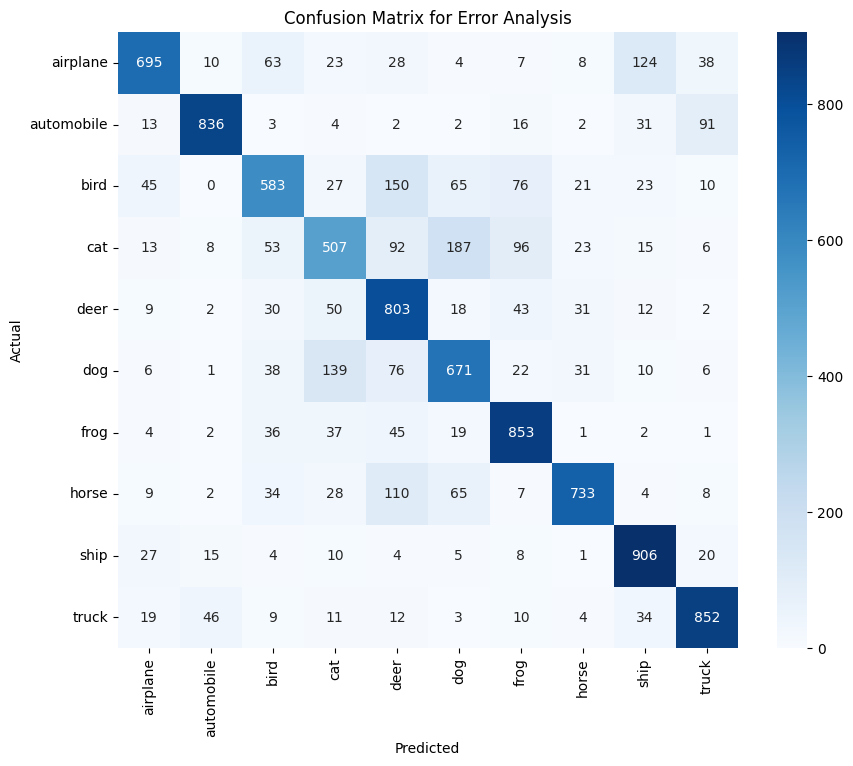

In [5]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predict on test set
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test.flatten()

# Part 2 Metrics: F1-Score, Precision, Recall
print("Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# Visualization: Confusion Matrix
plt.figure(figsize=(10,8))
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Error Analysis')
plt.show()

## 6) Evaluation 

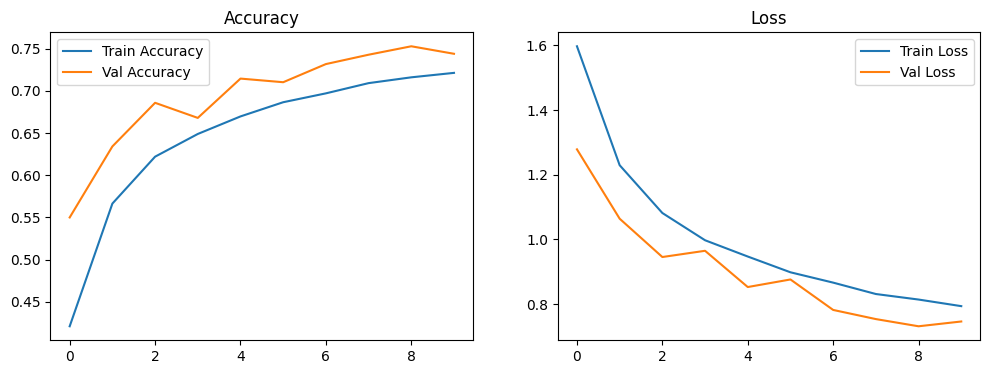

In [6]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend(); plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title('Loss')
plt.show()

## 7) Local XAI - Grad-CAM

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 32, 32, 3))
  warnings.warn(msg)


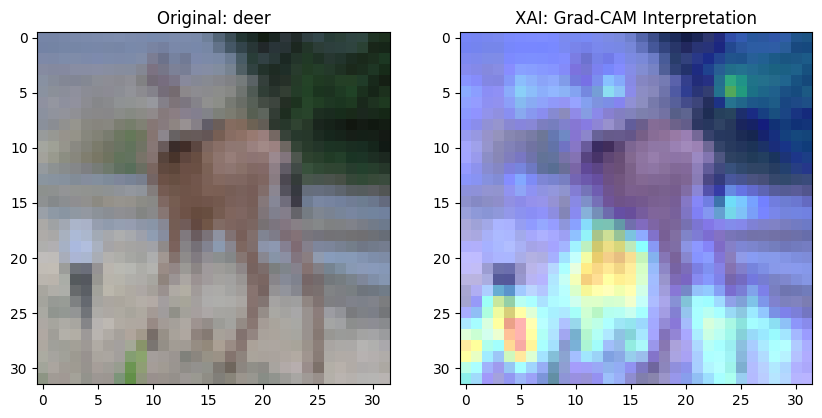

In [7]:
import cv2

def get_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Use the Functional API properties of the model
    last_conv_layer = model.get_layer(last_conv_layer_name)
    
    # Create a sub-model that outputs both the last conv layer and the final prediction
    grad_model = tf.keras.Model(
        inputs=model.inputs, 
        outputs=[last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Gradients of the predicted class w.r.t. the last conv layer output
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # Global Average Pooling of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weighted sum of feature maps
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize heatmap
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

# --- Visualization Code (Run this after re-training Cell 4) ---
img_index = 100 
img = np.expand_dims(x_test[img_index], axis=0)

heatmap = get_gradcam_heatmap(img, model, "last_conv_layer")

# Color mapping and superimposing
img_raw = x_test[img_index]
heatmap_resized = cv2.resize(heatmap, (32, 32))
heatmap_rescaled = np.uint8(255 * heatmap_resized)
jet_heatmap = cv2.applyColorMap(heatmap_rescaled, cv2.COLORMAP_JET)
jet_heatmap = cv2.cvtColor(jet_heatmap, cv2.COLOR_BGR2RGB) # Correct for Matplotlib

# Combine heatmap and original image
superimposed_img = (jet_heatmap * 0.4 / 255) + img_raw
superimposed_img = np.clip(superimposed_img, 0, 1)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_raw); plt.title(f"Original: {class_names[y_test[img_index][0]]}")
plt.subplot(1, 2, 2)
plt.imshow(superimposed_img); plt.title("XAI: Grad-CAM Interpretation")
plt.show()

## 8) Global/Local Hybrid XAI - SHAP

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(3, 32, 32, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(50, 32, 32, 3))']
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 519ms/step
Plotting explanations for: ['deer', 'dog', 'frog']


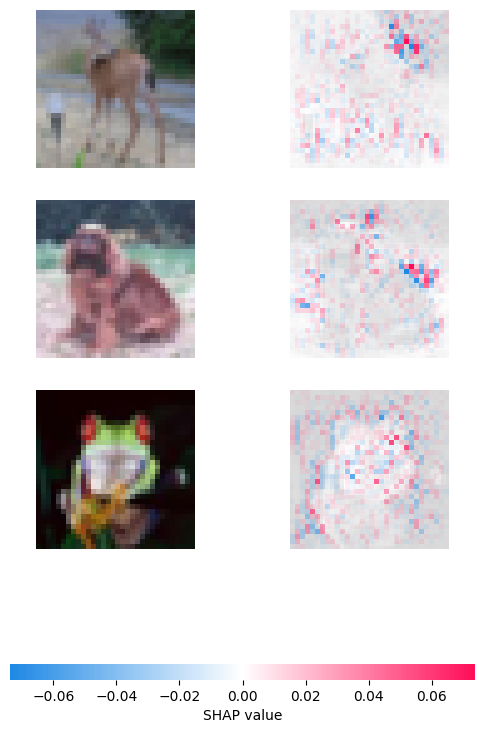

In [8]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup
background = x_train[:50] 
test_images = x_test[100:103]
explainer = shap.GradientExplainer(model, background)
shap_values = explainer.shap_values(test_images)

# 2. Get predictions to know which class to "explain"
preds = model.predict(test_images)
pred_indices = np.argmax(preds, axis=1)

# 3. Robust Indexing Logic
# We create a list that will only hold the 'Explanation' for the winning class
final_shap_to_plot = []

for i in range(len(test_images)):
    p_class = pred_indices[i]
    
    # Check if shap_values is a list (Standard) or a single numpy array (Newer versions)
    if isinstance(shap_values, list):
        # List structure: shap_values[class_index][sample_index]
        val = shap_values[p_class][i]
    else:
        # Array structure: shap_values[sample_index, ..., class_index]
        val = shap_values[i, :, :, :, p_class]
        
    final_shap_to_plot.append(val)

final_shap_to_plot = np.array(final_shap_to_plot)

# 4. Final Plotting
print(f"Plotting explanations for: {[class_names[idx] for idx in pred_indices]}")

# We pass it as [final_shap_to_plot] so SHAP treats it as a single 'reason' per image
# This fixes the black box issue by forcing the color scale to be visible
shap.image_plot([final_shap_to_plot], test_images)